In [1]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
#import gym_cartpole_swingup

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
#from stable_baselines.common.policies import MlpPolicy
from stable_baselines3 import PPO#2, A2C, ACKTR
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common import results_plotter

import matplotlib.pyplot as plt
import os
import yaml

import collections
import math

In [12]:
log_dir = "logs_nn"

for episodes in [50, 100, 200, 500, 1000]:
    log_dir = f"logs_nn_e={episodes}"
    os.makedirs(log_dir, exist_ok=True)

# Wrap Dynamic Model as Gym Environment

In [5]:
# ------------------------------------------------------------------
# Simple 3-Layer MLP
# ------------------------------------------------------------------
class MLP3(nn.Module):
    """A basic 3-layer perceptron: Input -> hidden1 -> hidden2 -> output.

    hidden_sizes: tuple (h1, h2)
    activation: callable returning nn.Module, e.g., nn.ReLU
    """
    def __init__(self, in_dim: int, out_dim: int, hidden_sizes=(128, 64), activation=nn.ReLU):
        super().__init__()
        h1, h2 = hidden_sizes
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            activation(),
            nn.Linear(h1, h2),
            activation(),
            nn.Linear(h2, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class CartPoleNNEnv (gym.Env):
    
    steps = 0
    model = None
    
    def __init__(self, model_filename="dyn_model.pth", window_size=4):
        self.episodes = model_filename.split('=')[-1].split('.')[0]  # Extract episodes from filename
        self.dyn_model = torch.load(model_filename, weights_only=False)
        self.device = next(self.dyn_model.parameters()).device
        self.window_size=window_size

        # load normalization constants
        with open(f'dyn_model_stats_e={self.episodes}.yaml', 'r') as f:
            stats = yaml.safe_load(f)
    
        # Convert back to tensors
        self.x_mean = torch.tensor(stats['x_mean'], dtype=torch.float32).to(self.device)
        self.x_std  = torch.tensor(stats['x_std'], dtype=torch.float32).to(self.device)
        self.y_mean = torch.tensor(stats['y_mean'], dtype=torch.float32).to(self.device)
        self.y_std  = torch.tensor(stats['y_std'], dtype=torch.float32).to(self.device)
        
        # FIFO-buffer that keeps the neural state
        self.stateBuffer = collections.deque(maxlen=window_size)
        
        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4
        
        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array([self.x_threshold * 2,
                         np.finfo(np.float32).max,
                         self.theta_threshold_radians * 2,
                         np.finfo(np.float32).max],
                        dtype=np.float32)

        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Box(-high, high, dtype=np.float32)

    def step (self, action):
        
        self.steps +=1
        
        # append last state + new action to state buffer
        netInput = [self.currentState[0], self.currentState[1],
                    self.currentState[2], self.currentState[3], 
                    action]
        self.stateBuffer.append (np.float64(netInput))
        state = np.array([list(self.stateBuffer)])
        
        # NN recall
        #netOutput = self.model.predict(np.float64(state))[0]
        with torch.no_grad():
            state_tensor = torch.flatten(torch.tensor(state, dtype=torch.float32)).to(self.device)
            state_tensor_norm = (state_tensor - self.x_mean) / self.x_std
            #print (state_tensor)
            y_pred_norm = self.dyn_model(state_tensor_norm)
            y_pred = y_pred_norm * self.y_std + self.y_mean
        netOutput = y_pred.squeeze(0).cpu().numpy()
                
        # retrieve new state
        self.currentState = np.float64([netOutput[0], netOutput[1], 
                                         netOutput[2], netOutput[3]])
        # check for episode termination
        cartPos = netOutput[0]
        pendPosDeg = np.degrees(netOutput[2])
        pendPosRad = netOutput[2]
        
        done=False
        if abs(cartPos) >= 2.4 or abs(pendPosDeg) >= 12 or self.steps > 200:
            done = True
            
        # compute reward
        rewardAngle = np.cos(pendPosRad)
        rewardPos = -abs(cartPos)
        
        return self.currentState, rewardAngle + rewardPos, done, False, {}
    
    def render (self):
        pass
    
    def reset(self, seed=0): 
        self.steps = 0
        
        # draw initial state
        initCartPos = 2. *np.random.random () - 1 # [-0.05, 0.05]
        initCartVel = 0
        initPendPos = 0
        initPendVel = 0
        
        # fill initial state
        for i in range (self.window_size):
            initState = np.float64([initCartPos, initCartVel, initPendPos, initPendVel, self.action_space.sample()])
            self.stateBuffer.append (initState)
            
        self.currentState = initState[0:4]
        
        return self.currentState, {}
        

# Instantiate monitored Gym environment

In [ ]:
envs = {}

for episodes in [50, 100, 200, 500, 1000]:
    env = CartPoleNNEnv(model_filename=f"dyn_model_e={episodes}.pth", window_size=4)
    log_dir = f"logs_nn_e={episodes}"
    env = Monitor(env, log_dir) # required for using callback functions during training
    env = DummyVecEnv([lambda: env])
    env = VecNormalize(env, norm_obs=True, norm_reward=True) # State normalization
    envs[episodes] = env

# Learn policy

### 1) Callback function for saving best model during training

In [7]:
from stable_baselines3.common.callbacks import BaseCallback
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param avg_episodes: (int) average over the past n episodes (default: 100)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    :param vec_norm_env: (VecNormalize) stable-baselines VecNormalize object (contains Gym env)
    """
    def __init__(self, check_freq: int, log_dir: str, verbose=1, avg_episodes=100, vec_norm_env=None):
        super(SaveOnBestTrainingRewardCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, 'best_model_nn')
        self.best_mean_reward = -np.inf
        self.best_timestep = -np.inf
        self.vec_norm_env = vec_norm_env
        self.avg_episodes = avg_episodes

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), 'timesteps')
            
            if len(x) > 0:
                # Mean training reward over the last avg_episodes episodes
                mean_reward = np.mean(y[-self.avg_episodes:])

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    self.best_timestep = self.num_timesteps
                    # Example for saving best model
                    if self.verbose > 0:
                        print("Saving new best model to {}".format(self.save_path))
                    self.model.save(self.save_path)
                    if self.vec_norm_env is not None: 
                        self.vec_norm_env.save ("%s.env_normalizations" % self.save_path)

                if self.verbose > 0:
                    print("Num timesteps: {}".format(self.num_timesteps))
                    print("Best mean reward: {:.2f} (ts={}) - Last mean reward per episode: {:.2f}".format(self.best_mean_reward, self.best_timestep, mean_reward))


        return True

### 2) Train Policy

In [46]:
models = {}

for episodes, env in envs.items():
    time_steps=101000

    #tensorboard_dir = "cartpole_tb_nn"
    #os.makedirs(tensorboard_dir, exist_ok=True)
    model = PPO('MlpPolicy', env, verbose=1) #, tensorboard_log=tensorboard_dir)

    log_dir = "logs_nn_e=%d" % episodes
    callback=SaveOnBestTrainingRewardCallback(check_freq=5000, log_dir=log_dir, avg_episodes=30, vec_norm_env=env)
    models[episodes] = model
    model.learn(total_timesteps=time_steps, callback=callback)

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24.2     |
|    ep_rew_mean     | 15.4     |
| time/              |          |
|    fps             | 885      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 30.7        |
|    ep_rew_mean          | 19.5        |
| time/                   |             |
|    fps                  | 721         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011789184 |
|    clip_fraction        | 0.147       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.685      |
|    explained_variance   | -0.165      |
|    learning

### Plot 

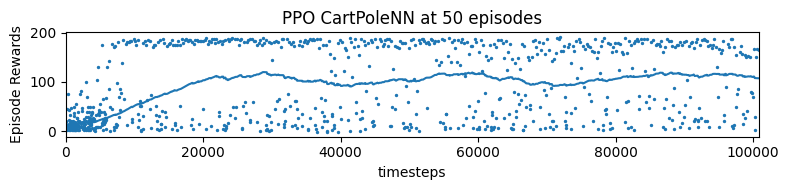

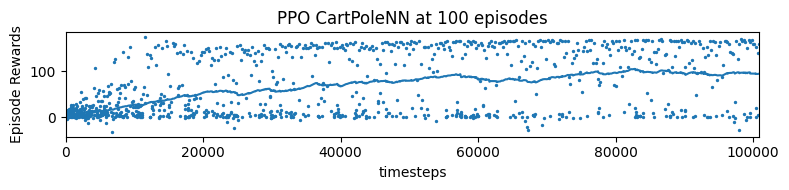

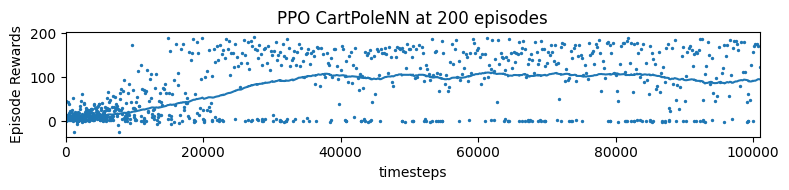

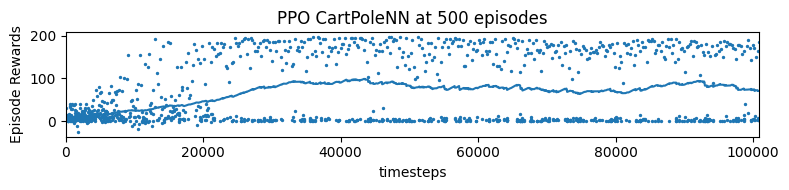

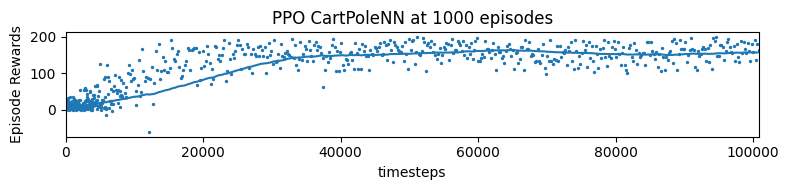

In [47]:
for episode in [50, 100, 200, 500, 1000]:
    log_dir = f"logs_nn_e={episode}"
    results_plotter.plot_results([log_dir], time_steps, results_plotter.X_TIMESTEPS, "PPO CartPoleNN at %d episodes" % episode)
    plt.savefig(f"results-cartpoleNN_{episode}.png")
    plt.show()

# Model inference: Evaluate policy

### load best policy

In [48]:
best_models = {}
for episodes in [50, 100, 200, 500, 1000]:
    log_dir = f"logs_nn_e={episodes}"
    model = PPO.load("%s/best_model_nn.zip" % log_dir)
    best_models[episodes] = model

In [28]:
best_models

{50: <stable_baselines3.ppo.ppo.PPO at 0x1604158d000>,
 100: <stable_baselines3.ppo.ppo.PPO at 0x16044e89f90>,
 200: <stable_baselines3.ppo.ppo.PPO at 0x16045d8ca90>,
 500: <stable_baselines3.ppo.ppo.PPO at 0x16044fdf9d0>,
 1000: <stable_baselines3.ppo.ppo.PPO at 0x16044f76bc0>}

### Evaluate on environment from where NN data was sampled from

In [49]:
import random

seeds = range(20)

results = {}
for episodes in [50, 100, 200, 500, 1000]:
    log_dir = f"logs_nn_e={episodes}"
    model = best_models[episodes]
    results[episodes] = {
        'mean_reward': None,
        'std_reward': None,
        'rewards': [],
        'episode_lengths': []
    }
    for seed in seeds:
        # Set the random seed for reproducibility
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)

        env = DummyVecEnv([lambda: gym.make("CartPole-v1", render_mode="human")])
        # Load the saved statistics
        env = VecNormalize.load("%s/best_model_nn.env_normalizations" % log_dir, env)
        env.training=False
        #np.random.seed(seed)
        
        env.seed(seed)
        state = env.reset()

        # note: state is the VecNormalize-scaled observation (each model has its own obs statistics),
        # so it differs between constellations. The raw start state is identical for the same seed:
        print(f"seed={seed}, raw_state={env.get_original_obs()}")
        done=False
        cumReward = 0
        steps=0

        while not done: 
            steps += 1
            action, _states = model.predict(state)
            state, reward, done, _ = env.step(action)
            cumReward += reward
            env.render() ## <- comment out in Google colab

        results[episodes]['rewards'].append(cumReward)
        results[episodes]['episode_lengths'].append(steps)
     
        print (f"steps={steps}, cumReward={cumReward}")
    
    env.close()
    results[episodes]['mean_reward'] = np.mean(results[episodes]['rewards'])
    results[episodes]['std_reward'] = np.std(results[episodes]['rewards'])

print(results)


seed=0, raw_state=[[ 0.01369617 -0.02302133 -0.04590265 -0.04834723]]
steps=110, cumReward=[4.2237563]
seed=1, raw_state=[[ 0.00118216  0.04504637 -0.03558404  0.04486495]]
steps=163, cumReward=[6.258839]
seed=2, raw_state=[[-0.02383879 -0.02015088  0.03142257 -0.04080841]]
steps=75, cumReward=[2.8798337]
seed=3, raw_state=[[-0.04143508 -0.02631895  0.03012745  0.0082162 ]]
steps=65, cumReward=[2.4958558]
seed=4, raw_state=[[ 0.04430561  0.00113276  0.04762437 -0.0419164 ]]
steps=64, cumReward=[2.457458]
seed=5, raw_state=[[ 0.03050029  0.03079408  0.00153256 -0.02141986]]
steps=67, cumReward=[2.5726514]
seed=6, raw_state=[[ 0.00381644 -0.01567291 -0.01309328 -0.01255032]]
steps=109, cumReward=[4.1853585]
seed=7, raw_state=[[ 0.01250955  0.03972138  0.02756857 -0.02747928]]
steps=57, cumReward=[2.1886735]
seed=8, raw_state=[[-0.01730277  0.04872768 -0.01812892  0.02885489]]
steps=71, cumReward=[2.7262425]
seed=9, raw_state=[[ 0.03702492 -0.02131828  0.01031481  0.02775341]]
steps=82, c

,mittl. Episodenlänge,std Episodenlänge,mittl. Reward (norm.),std Reward (norm.)
N (Episoden),,,,
50,82.8,23.97,3.18,0.92
100,45.2,7.23,1.92,0.31
200,500.0,0.00,22.11,0.00
500,500.0,0.00,19.60,0.00
1000,500.0,0.00,20.64,0.00


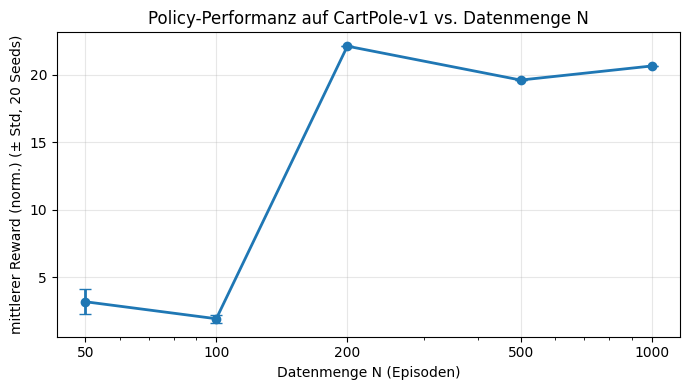

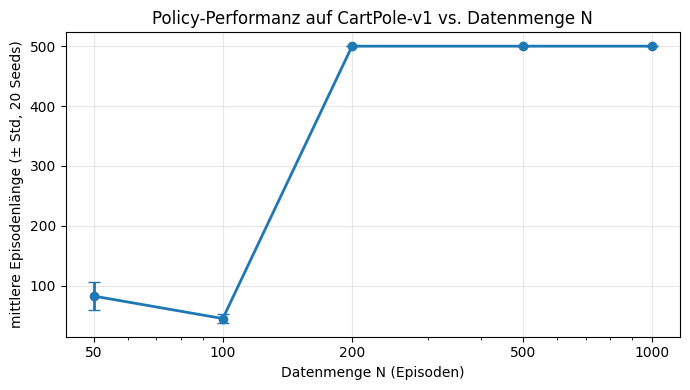

In [50]:
import pandas as pd
rows = []
for episodes, res in results.items():
    lens = np.asarray(res['episode_lengths'], dtype=float)
    rews = np.asarray(res['rewards'], dtype=float).flatten()
    rows.append({
        'N (Episoden)': episodes,
        'mittl. Episodenlänge': lens.mean(),
        'std Episodenlänge': lens.std(),
        'mittl. Reward (norm.)': rews.mean(),
        'std Reward (norm.)': rews.std(),
    })
df_results = pd.DataFrame(rows).set_index('N (Episoden)').sort_index()
display(df_results.round(2))


fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(df_results.index, df_results['mittl. Reward (norm.)'],
            yerr=df_results['std Reward (norm.)'],
            marker='o', markersize=6, lw=2, capsize=4)
ax.set_xscale('log')
ax.set_xticks(df_results.index)
ax.xaxis.set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Datenmenge N (Episoden)')
ax.set_ylabel('mittlerer Reward (norm.) (± Std, 20 Seeds)')
ax.set_title('Policy-Performanz auf CartPole-v1 vs. Datenmenge N')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results-performance_vs_N.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(df_results.index, df_results['mittl. Episodenlänge'],
            yerr=df_results['std Episodenlänge'],
            marker='o', markersize=6, lw=2, capsize=4)
ax.set_xscale('log')
ax.set_xticks(df_results.index)
ax.xaxis.set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Datenmenge N (Episoden)')
ax.set_ylabel('mittlere Episodenlänge (± Std, 20 Seeds)')
ax.set_title('Policy-Performanz auf CartPole-v1 vs. Datenmenge N')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results-performance_vs_N.png', dpi=150)
plt.show()

1. Ab welcher Datenmenge entstehen deutliche Verbesserungen? Ab 200 episoden, siehe PPO Plot und Plot Aufgabe 1.
2. Gibt es Sättigungseffekte bei Modell- oder Policy-Qualität? Ja, aber müsste man nach 1000 Episoden weiter untersuchen.
3. Welche typischen Fehler zeigen sich bei kleinen Datensätzen? Schlechte Abdeckung des Zustandsraums.
4. Spiegelt gute Forecast-Qualität automatisch gute Policy-Performanz wider? Eine gutes Dynamikmodel sagt wenig über PPO Performance aus. 1-Schritt Vorhersage kann fehlleiten. Policy wird nicht unbedingt besser mit höherer Forecast-Qualität.